# STL-Rocket: Local and Global Explanations of Time-Series Classifiers


## Setup

In [8]:
import copy
from collections import defaultdict
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import minimize_scalar
from scipy.stats import gaussian_kde
from sklearn.linear_model import LogisticRegressionCV
from aeon.datasets import load_classification
from stlkernel.distribution_formulae import F0
from torcheck.stl import Atom, Not, And, Or, Globally, Eventually, Until
from torcheck import simplify
torch.manual_seed(42)
np.random.seed(42)

## Dataset

In [9]:
# Datasets
# "ArticularyWordRecognition"
# "BasicMotions"
# "ERing"
# "Epilepsy"
# "Libras"


In [10]:
DS_NAME = "BasicMotions"

X_tr, y_tr = load_classification(DS_NAME, split="TRAIN")
X_te, y_te = load_classification(DS_NAME, split="TEST")
classes = np.unique(y_tr)
N, V, T    = X_tr.shape

print(f"train: {X_tr.shape}, test: {X_te.shape}")
print(f"classes: {classes}")

train: (40, 6, 100), test: (40, 6, 100)
classes: ['badminton' 'running' 'standing' 'walking']


/tmp/ipykernel_48382/2666882695.py:3: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_tr, y_tr = load_classification(DS_NAME, split="TRAIN")
/tmp/ipykernel_48382/2666882695.py:4: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X_te, y_te = load_classification(DS_NAME, split="TEST")


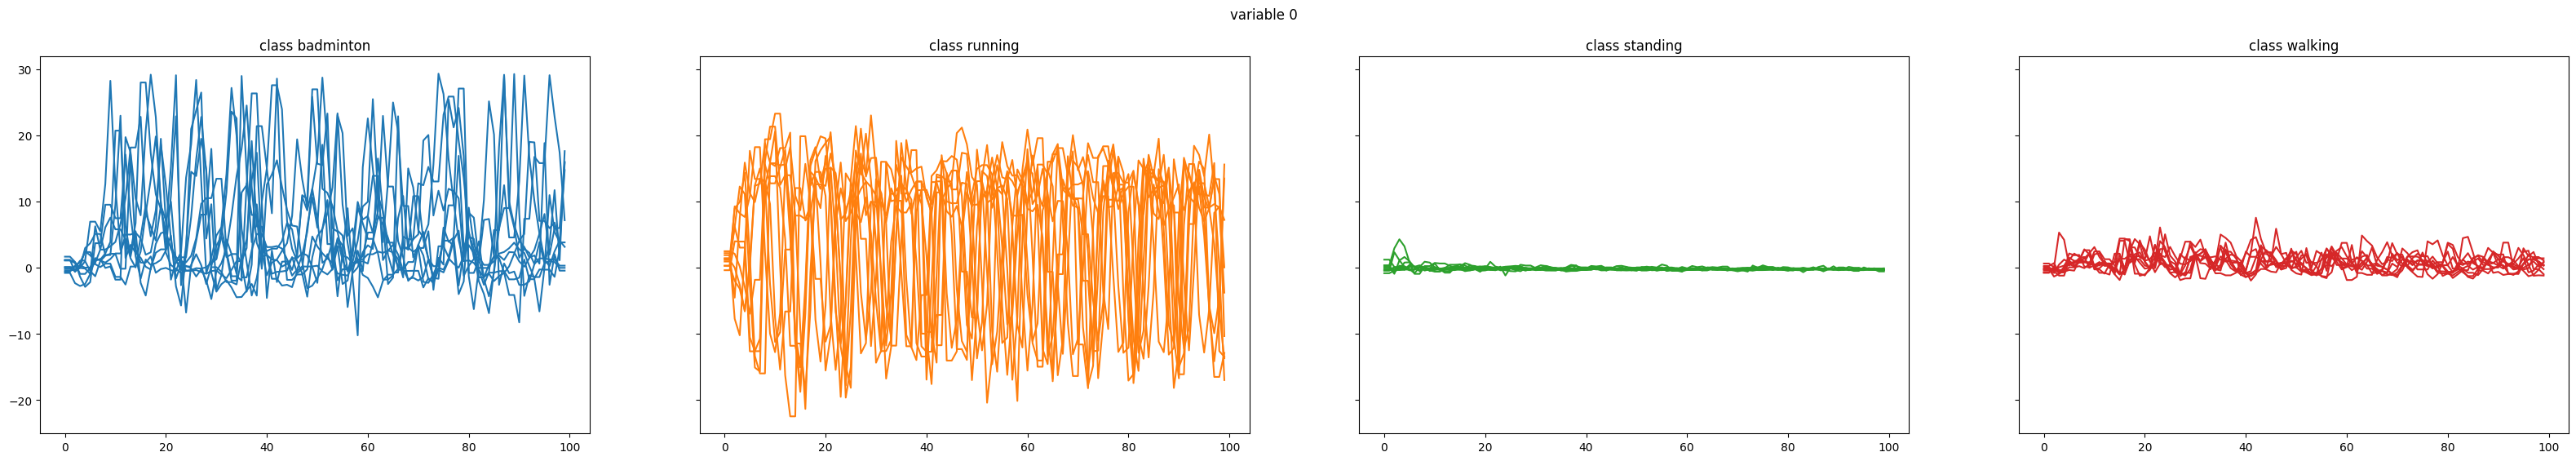

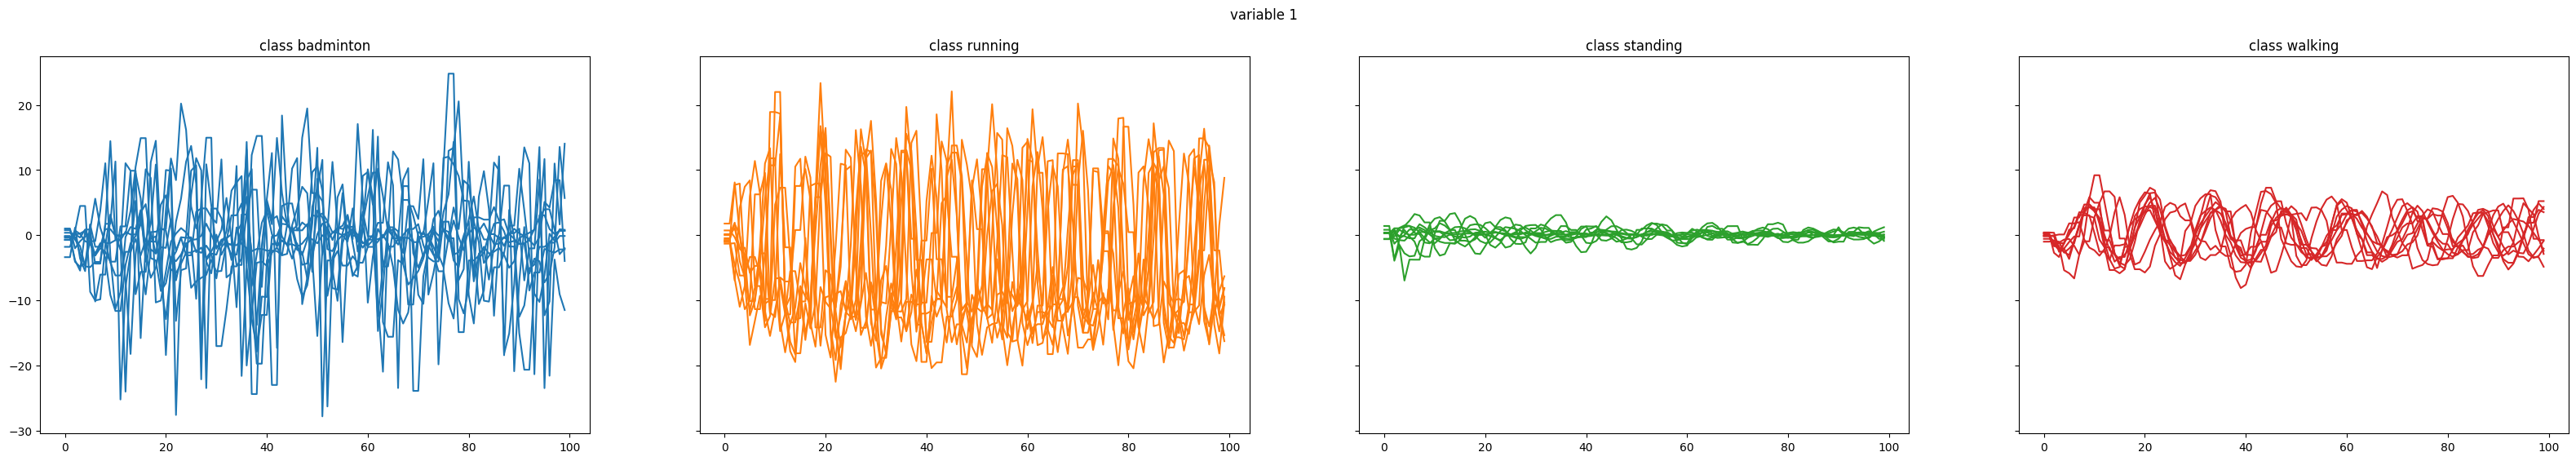

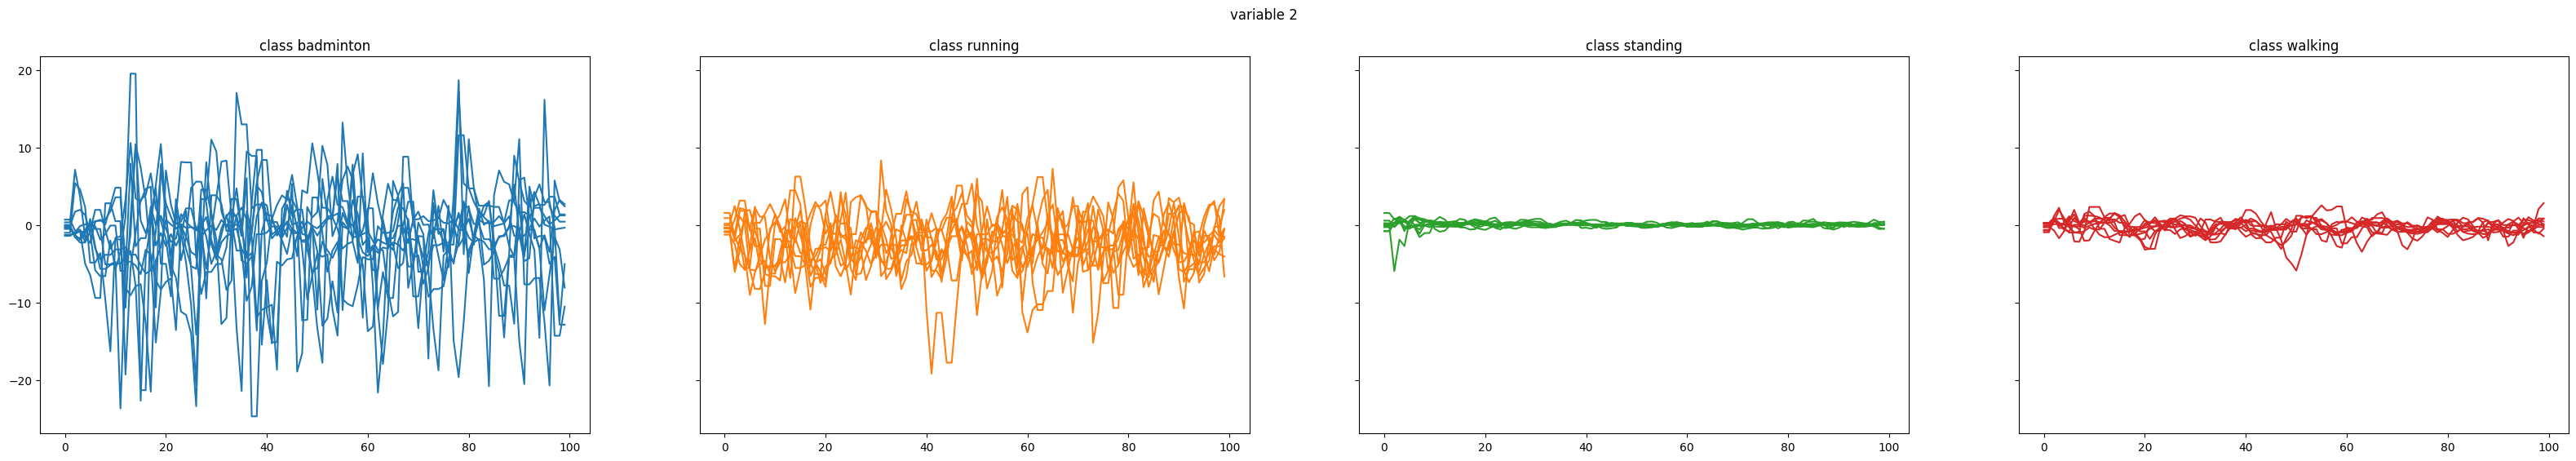

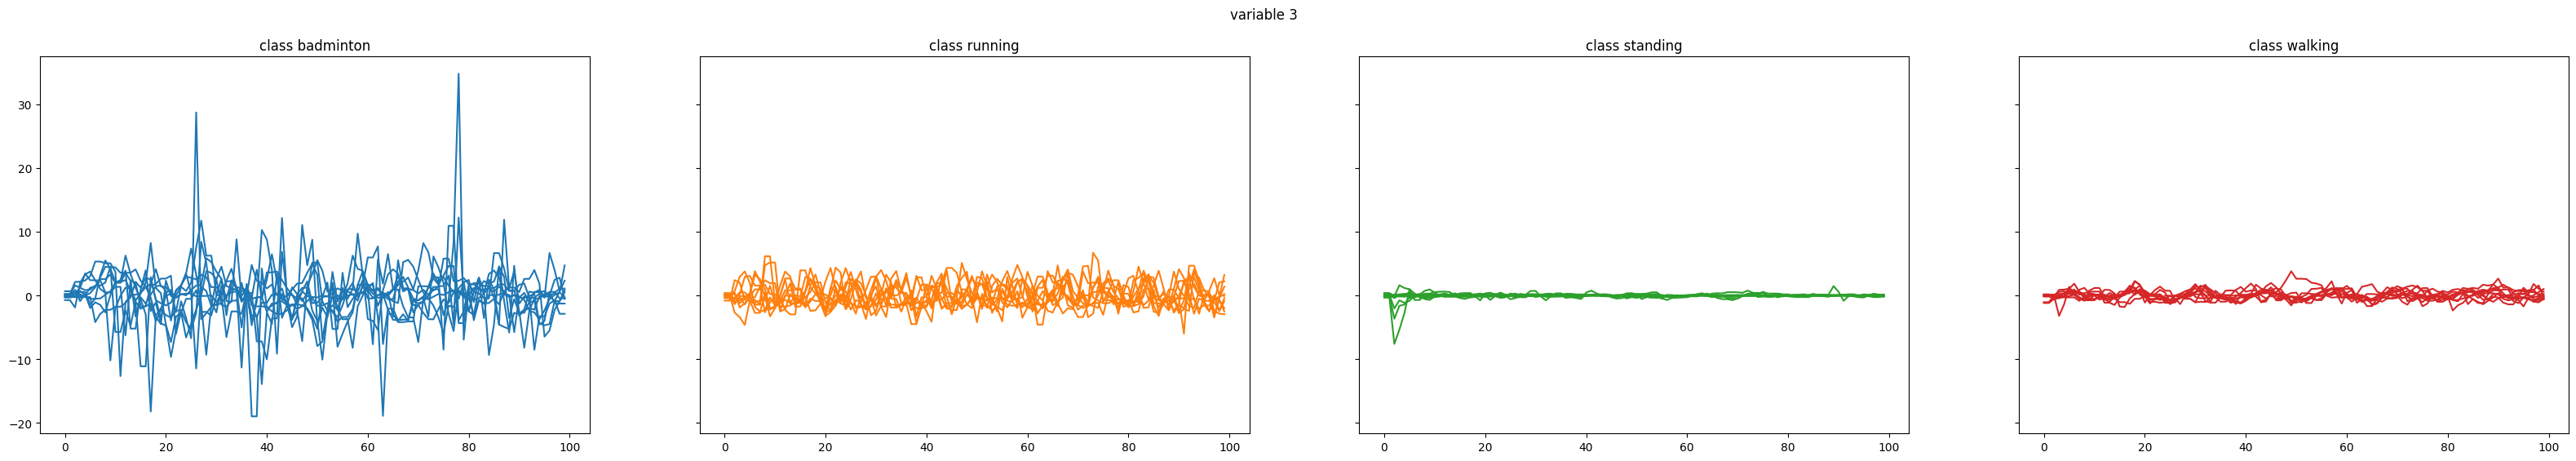

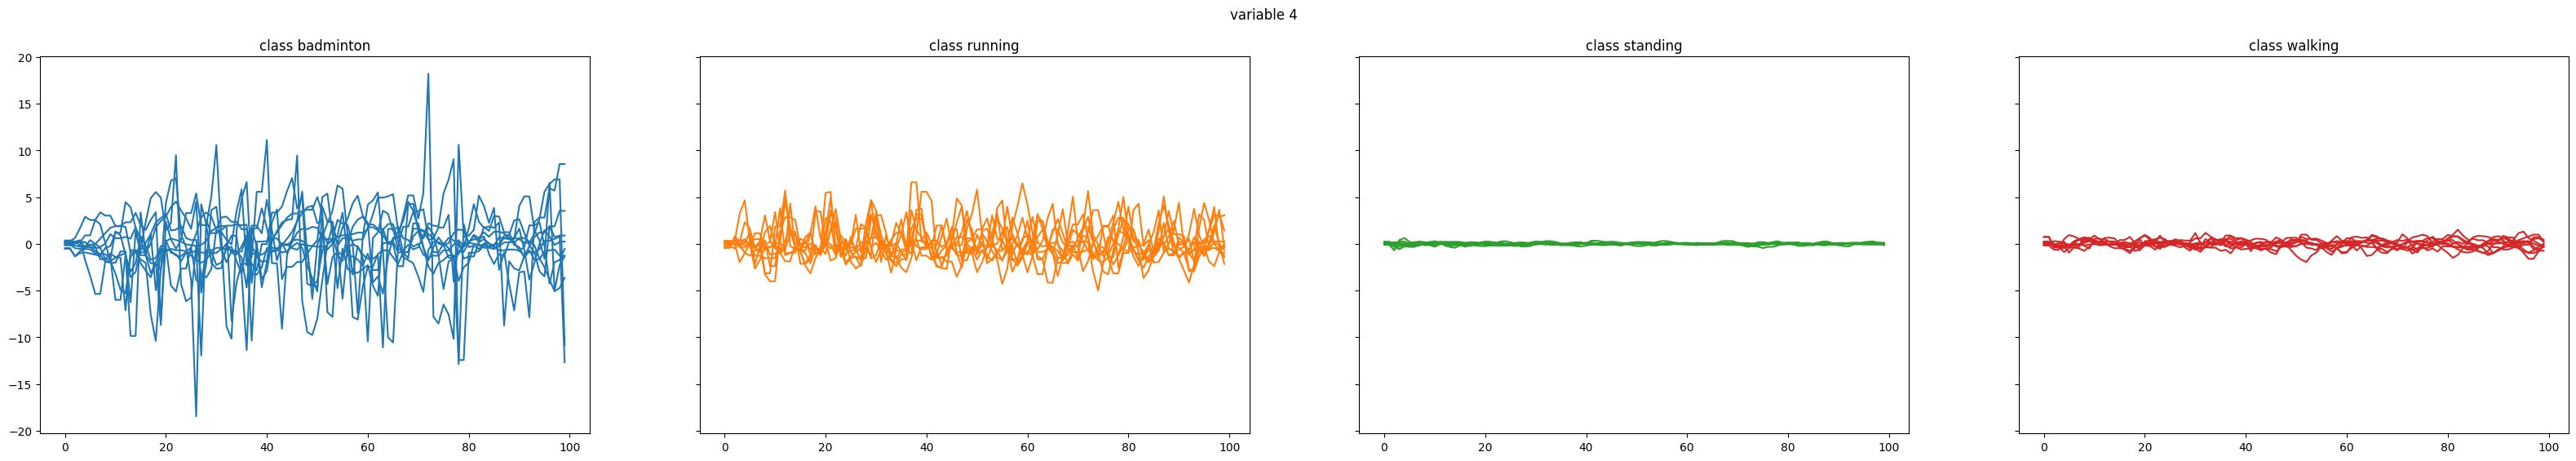

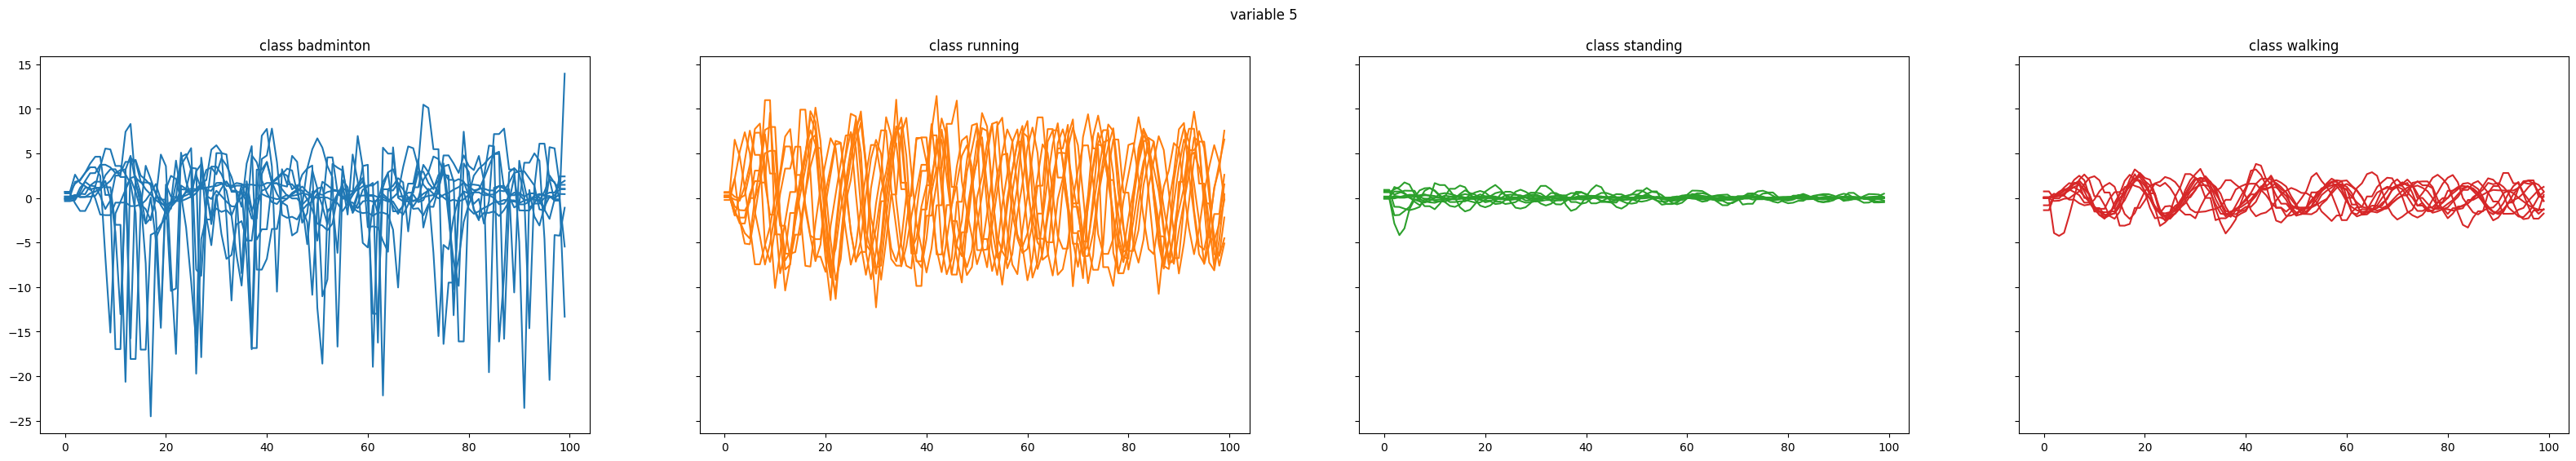

In [11]:
for v in range(V):
    fig, ax = plt.subplots(1, len(classes), sharey=True, figsize=(40,6))
    for i, c in enumerate(classes):
        ax[i].plot(X_tr[y_tr == c][:, v].T, c=f"C{i}")
        ax[i].set_title(f"class {c}")
    fig.suptitle(f"variable {v}")
    plt.show()

## Feature Extraction



In [12]:
class StateVariableStandardScaler:
    def __init__(self, eps=1e-8):
        self.mean = None
        self.std = None
        self.eps = eps

    def fit(self, X):
        self.mean = np.mean(X, axis=(0, 2), keepdims=True)
        self.std = np.std(X, axis=(0, 2), keepdims=True) 
        return self

    def transform(self, X):
        return (X - self.mean) / (self.std + self.eps)

    def fit_transform(self, X):
        return self.fit(X).transform(X)


def eval_robustness(phi, X):
    with torch.no_grad():
        rho = phi.quantitative(torch.from_numpy(X), evaluate_at_all_times=False, normalize=False)

    return rho.detach().cpu().numpy().ravel()


def extract_features(X, formulas):
    with torch.no_grad():
        feats = [
            phi.quantitative(torch.from_numpy(X), evaluate_at_all_times=False, normalize=False).detach().cpu().numpy()
            for phi in formulas
        ]
    return np.stack(feats, axis=1)


def shift_atom_thresholds(node, delta, sign=1):
    if isinstance(node, Atom):
        effective_delta = delta * sign
        if node.lte:
            node.threshold += effective_delta   # rho = threshold - x
        else:
            node.threshold -= effective_delta   # rho = x - threshold
    elif isinstance(node, Not):
        shift_atom_thresholds(node.child, delta, sign=-sign)
    elif isinstance(node, (And, Or)):
        shift_atom_thresholds(node.left_child, delta, sign)
        shift_atom_thresholds(node.right_child, delta, sign)
    elif isinstance(node, (Globally, Eventually)):
        shift_atom_thresholds(node.child, delta, sign)
    elif isinstance(node, Until):
        shift_atom_thresholds(node.left_child, delta, sign)
        shift_atom_thresholds(node.right_child, delta, sign)
    else:
        raise TypeError(f"unknown node type: {type(node).__name__}")


def plot_robustness_kde(phi, X, y, classes, title=None):
    rho = eval_robustness(phi, X)
    grid = np.linspace(rho.min() - 1, rho.max() + 1, 400)
    fig, ax = plt.subplots(figsize=(8, 3.5))
    for c in classes:
        rho_c = rho[y == c]
        if rho_c.size < 2 or np.allclose(rho_c.std(), 0):
            ax.axvline(rho_c.mean(), linestyle="--",
                       label=f"{c} (n={rho_c.size}, degenerate)")
            continue
        kde = gaussian_kde(rho_c, 0.1)
        ax.plot(grid, kde(grid), label=f"{c} (n={rho_c.size})")
    ax.axvline(0, color="black", linewidth=0.8, linestyle=":", label="rho = 0")
    ax.set_xlabel("rho"); ax.set_ylabel("density")
    if title is not None:
        ax.set_title(title)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

In [13]:
N_FORMULAS     = 1000
DEPTH_MAX      = 5
SEED           = 1
BATCH          = 200
THRESHOLD_CORR = 0.98
MAX_ITER       = 20

scaler = StateVariableStandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

v_min = np.amin(X_tr, axis=(0, 2))
v_max = np.amax(X_tr, axis=(0, 2))
generator = F0(
    n_vars=V, v_min=v_min, v_max=v_max,
    t_max=T - 1, depth_max=DEPTH_MAX, seed=SEED,
    only_temporal=True, until_weight=0.0
)

formulas    = []
X_tr_feats  = np.zeros((X_tr.shape[0], 0))
X_te_feats  = np.zeros((X_te.shape[0], 0))

for it in range(MAX_ITER):
    needed = N_FORMULAS - len(formulas)
    if needed <= 0:
        break

    # Ask for more than needed since some will be dropped by the corr filter.
    print("Generating formulae")
    batch = generator.sample(max(needed, BATCH))

    print("Extracting features train...")
    new_tr = extract_features(X_tr, batch)
    print("Extracting features test...")
    new_te = extract_features(X_te, batch)

    # Center new features (and shift the formula thresholds to match).
    print("Centering features...")
    for i, phi in enumerate(batch):
        delta = -new_tr[:, i].mean()
        new_tr[:, i] += delta
        new_te[:, i] += delta
        shift_atom_thresholds(phi, delta)

    # Concatenate kept + new, then drop correlated.
    # The filter keeps the leftmost of each correlated pair, so previously
    # kept columns are guaranteed to survive.
    combined_tr       = np.concatenate([X_tr_feats, new_tr], axis=1)
    combined_te       = np.concatenate([X_te_feats, new_te], axis=1)
    combined_formulas = formulas + batch
    print("Computing corr...")

    corr  = np.corrcoef(combined_tr, rowvar=False)
    upper = np.triu(np.ones(corr.shape), k=1).astype(bool)
    drop  = [i for i in range(corr.shape[1])
             if np.any(np.abs(corr[upper[:, i], i]) > THRESHOLD_CORR)]
    keep  = np.setdiff1d(np.arange(corr.shape[1]), drop)

    formulas   = [combined_formulas[i] for i in keep]
    X_tr_feats = combined_tr[:, keep]
    X_te_feats = combined_te[:, keep]

    print(f"Iter {it}: kept {len(formulas)} / {N_FORMULAS} "
          f"(dropped {len(drop)} this round)")

# Trim any overshoot.
if len(formulas) > N_FORMULAS:
    formulas   = formulas[:N_FORMULAS]
    X_tr_feats = X_tr_feats[:, :N_FORMULAS]
    X_te_feats = X_te_feats[:, :N_FORMULAS]

print(f"Final: {X_tr_feats.shape}, test {X_te_feats.shape}")

Generating formulae
Extracting features train...
Extracting features test...
Centering features...
Computing corr...
Iter 0: kept 394 / 1000 (dropped 606 this round)
Generating formulae
Extracting features train...
Extracting features test...
Centering features...
Computing corr...
Iter 1: kept 602 / 1000 (dropped 398 this round)
Generating formulae
Extracting features train...
Extracting features test...
Centering features...
Computing corr...
Iter 2: kept 736 / 1000 (dropped 264 this round)
Generating formulae
Extracting features train...
Extracting features test...
Centering features...
Computing corr...
Iter 3: kept 815 / 1000 (dropped 185 this round)
Generating formulae
Extracting features train...
Extracting features test...
Centering features...
Computing corr...
Iter 4: kept 879 / 1000 (dropped 136 this round)
Generating formulae
Extracting features train...
Extracting features test...
Centering features...
Computing corr...
Iter 5: kept 926 / 1000 (dropped 153 this round)
Gene

## Classifier


In [22]:
model = LogisticRegressionCV(
    Cs= np.logspace(-4, 4, 10),
    l1_ratios=[1.0],
    fit_intercept=False,
    solver="saga",
    cv=3,
    max_iter=1000,
    class_weight="balanced",
    use_legacy_attributes=False,
)
model.fit(X_tr_feats, y_tr)

W = model.coef_                          # (K, M)
b = model.intercept_                     # (K,) -> all zeros, kept for code uniformity

print(f"test accuracy: {model.score(X_te_feats, y_te):.3f}")
print(f"non-zero columns of W: {(W != 0).any(axis=0).sum()} / {W.shape[1]}")

/home/alessandro/Projects/.env/lib64/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/alessandro/Projects/.env/lib64/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/alessandro/Projects/.env/lib64/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/alessandro/Projects/.env/lib64/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/alessandro/Projects/.env/lib64/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/alessandr

test accuracy: 1.000
non-zero columns of W: 273 / 1000


/home/alessandro/Projects/.env/lib64/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## Single-Sample Local Explanation

In [23]:
def per_competitor_contributions(W, x, class_idx, others):
    if W.shape[0] == 1:
        return np.stack([W[0]*x])
    return np.stack([(W[class_idx] - W[k]) * x for k in others])


def get_top_m_features(contrib_matrix, m):
    agg = contrib_matrix.sum(axis=0)
    order = np.argsort(-agg)
    return order[:m].tolist(), agg


def reparametrize_formula(phi_original, X, y, target_class):
    y = np.asarray(y)
    phi = copy.deepcopy(phi_original)
    rho = eval_robustness(phi, X)
    target_mask = (y == target_class)
    med_target = np.median(rho[target_mask])
    other_classes = np.unique(y[~target_mask])
    med_others = {c: np.median(rho[y == c]) for c in other_classes}
    below = {c: m for c, m in med_others.items() if m < med_target}
    above = {c: m for c, m in med_others.items() if m > med_target}

    if len(below) == 0:                          # Target A1 A2 ...
        ref_class = min(above, key=lambda c: above[c])
    elif len(above) == 0:                        # ... A2 A1 Target
        ref_class = max(below, key=lambda c: below[c])
    elif len(above) == len(below):               # ... A2 Target A1 ...
        ref_class = max(med_others, key=lambda c: abs(med_others[c] - med_target))
    elif len(below) > len(above):                # A2 A1 Target A3
        ref_class = max(below, key=lambda c: below[c])
    else:                                        # A2 Target A1 A3
        ref_class = min(above, key=lambda c: above[c])

    med_ref = med_others[ref_class]
    negated = med_target < med_ref               
    if negated:
        phi = Not(phi)
        med_target = -med_target
        med_ref    = -med_ref

    delta_star = -(med_target + med_ref) / 2
    phi_new = copy.deepcopy(phi)
    shift_atom_thresholds(phi_new, delta_star)

    return phi_new


def greedy_precise_picks(x, W, b, model, formulas, X_tr_t, y_tr,
                         class_idx, pool_size=10, precision_threshold=0.9):
    """
    Two-stage local explanation selection:
      1. Candidate pool: top-pool_size formulas by summed margin contribution.
      2. Greedy selection from pool by precision gain on training trajectories,
         stopping when precision >= precision_threshold.
    """
    target_class = model.classes_[class_idx]
    others = [k for k in range(len(model.classes_)) if k != class_idx]

    # Stage 1: cheap margin-sum heuristic to build candidate pool
    contrib = per_competitor_contributions(W, x, class_idx, others)
    pool_indices, _ = get_top_m_features(contrib, pool_size)

    # Stage 2: greedy precision-guided selection from pool
    remaining = list(pool_indices)
    picks = []
    reparametrized = {}
    rho_current = np.full(len(y_tr), np.inf)  # empty conjunction: vacuously satisfied

    for _ in range(len(remaining)):
        best_j, best_precision, best_rho, best_phi = None, -np.inf, None, None

        for j in remaining:
            phi_j = reparametrize_formula(formulas[j], X_tr_t, y_tr, target_class)
            rho_j = eval_robustness(phi_j, X_tr_t)
            rho_combined = np.minimum(rho_current, rho_j)

            pos_mask = rho_combined > 0
            tot = pos_mask.sum()
            precision = float((y_tr[pos_mask] == target_class).sum() / tot) if tot > 0 else 0.0

            if precision > best_precision:
                best_precision, best_j, best_rho, best_phi = precision, j, rho_j, phi_j

        picks.append(best_j)
        remaining.remove(best_j)
        reparametrized[best_j] = best_phi
        rho_current = np.minimum(rho_current, best_rho)

        if best_precision >= precision_threshold:
            break

    return picks, reparametrized

## Local Explanations



In [24]:
def conjunction(phis):
    if not phis:
        raise ValueError("empty conjunction")
    out = phis[0]
    for phi in phis[1:]:
        out = And(out, phi)
    return simplify(out)

def build_local_explanation(x, W, b, model, formulas, X_tr_t, y_tr,
                      pool_size=20, precision_threshold=0.9):
    """Build a conjunction of reparametrized formulas for one sample.

    Candidates are pre-filtered to the top-pool_size by margin contribution,
    then selected greedily by precision until precision_threshold is reached.
    """
    if W.shape[0] == 1:          # sklearn binary case: coef_ is (1, M), expand to (2, M)
        W = np.vstack([-W, W])
        b = np.array([-b[0], b[0]])
    scores = W @ x + b
    class_idx = int(np.argmax(scores))
    target_class = model.classes_[class_idx]

    picks, reparametrized = greedy_precise_picks(
        x, W, b, model, formulas, X_tr_t, y_tr,
        class_idx, pool_size=pool_size, precision_threshold=precision_threshold,
    )

    phis = [reparametrized[j] for j in picks]
    return conjunction(phis), target_class, picks


def evaluate_local_explanation(phi_local, target_class, X_tr, y_tr):
    # Compute P(y(x')=y(x) | rho(phi_local(x), x') > 0)
    rhos = eval_robustness(phi_local, X_tr)
    pos_mask = rhos > 0
    tot_positive = pos_mask.sum()
    if tot_positive == 0:
        return 0.0

    true_positive = (y_tr[pos_mask] == target_class).sum()
    precision = float(true_positive / tot_positive)

    return precision, true_positive, tot_positive

# Global Explanation

In [25]:
def disjunction(phis):
    if not phis:
        raise ValueError("empty disjunction")
    out = phis[0]
    for phi in phis[1:]:
        out = Or(out, phi)
    return out


def build_global_explanations(X_te_feats_np, W, b, model, formulas, X_tr_t, y_tr,
                               pool_size=20, precision_threshold=0.9):
    locals_per_class = defaultdict(list)
    n_test = X_te_feats_np.shape[0]

    for i in range(n_test):
        phi_local, target_class, picks = build_local_explanation(
            X_te_feats_np[i], W, b, model, formulas,
            X_tr_t, y_tr, pool_size=pool_size, precision_threshold=precision_threshold,
        )
        local_precision, n_tp, n_pos = evaluate_local_explanation(phi_local, target_class, X_tr_t, y_tr)
        print(f"Sample {i:3d} | class {target_class} | {len(picks)} formulas | precision {local_precision:.2f} rate {n_tp}/{n_pos}")
        locals_per_class[target_class].append((i, phi_local, picks))

    global_per_class = {}
    n_unique_per_class = {}
    for cls, lst in locals_per_class.items():
        seen = {}
        for _, phi, _ in lst:
            key = str(phi)
            if key not in seen:
                seen[key] = phi
        unique_phis = list(seen.values())
        n_unique_per_class[cls] = len(unique_phis)
        global_per_class[cls] = disjunction(unique_phis)

    return global_per_class, locals_per_class, n_unique_per_class

In [26]:
POOL_SIZE = 10
PRECISION_THRESHOLD = 0.75

global_per_class, locals_per_class, n_unique_per_class = build_global_explanations(
    X_te_feats, W, b, model, formulas,
    X_tr, y_tr, pool_size=POOL_SIZE, precision_threshold=PRECISION_THRESHOLD,
)

print(f"\nGlobal explanations built:")
for cls, lst in locals_per_class.items():
    print(f"  {cls:<12s}  {len(lst):3d} local explanations  "
          f"{n_unique_per_class[cls]} unique")

Sample   0 | class standing | 1 formulas | precision 1.00 rate 9/9
Sample   1 | class standing | 1 formulas | precision 1.00 rate 9/9
Sample   2 | class standing | 1 formulas | precision 1.00 rate 10/10
Sample   3 | class standing | 1 formulas | precision 1.00 rate 10/10
Sample   4 | class standing | 1 formulas | precision 1.00 rate 9/9
Sample   5 | class standing | 1 formulas | precision 1.00 rate 9/9
Sample   6 | class standing | 1 formulas | precision 1.00 rate 9/9
Sample   7 | class standing | 1 formulas | precision 1.00 rate 9/9
Sample   8 | class standing | 1 formulas | precision 1.00 rate 9/9
Sample   9 | class standing | 1 formulas | precision 1.00 rate 9/9
Sample  10 | class running | 1 formulas | precision 1.00 rate 10/10
Sample  11 | class running | 1 formulas | precision 1.00 rate 10/10
Sample  12 | class running | 1 formulas | precision 1.00 rate 10/10
Sample  13 | class running | 1 formulas | precision 1.00 rate 10/10
Sample  14 | class running | 1 formulas | precision 1.

## 10. Evaluation Global Explanations



Evaluation on test set:
class         #unique   coverage    FP rate
--------------------------------------------
standing            3    100.0%      0.0%
running             2    100.0%      3.3%
walking             2    100.0%      0.0%
badminton           2    100.0%      6.7%
( ( ( G[27,inf]( ( F(x_1 => 5.4094) ) ∨ (x_3 <= 0.5068) ) ) ∨ ( ( (x_0 => 5.1746) ∨ ( (x_1 <= -11.4409) ∧ (x_1 <= -6.0858) ) ) ∨ ( G[6,58](x_3 <= 0.4853) ) ) ) ∨ ( (x_5 <= -7.2777) ∨ ( ( G[21,inf](x_3 <= 0.5188) ) ∨ (x_5 => 13.5723) ) ) )


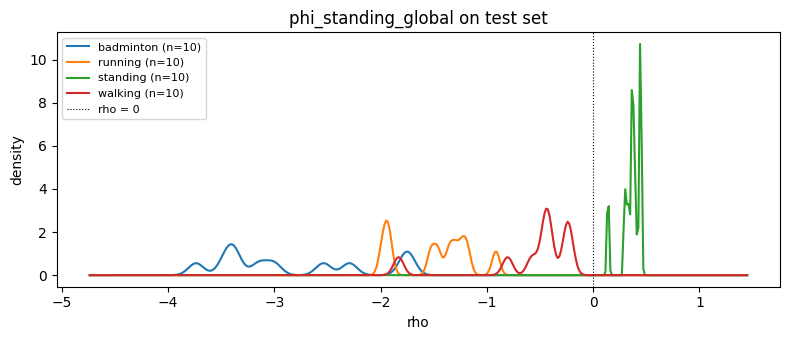

( ( ( G(x_4 => -2.8362) ) ∧ ( F[49,inf](x_0 => 1.061) ) ) ∨ ( F( F(x_0 <= -2.077) ) ) )


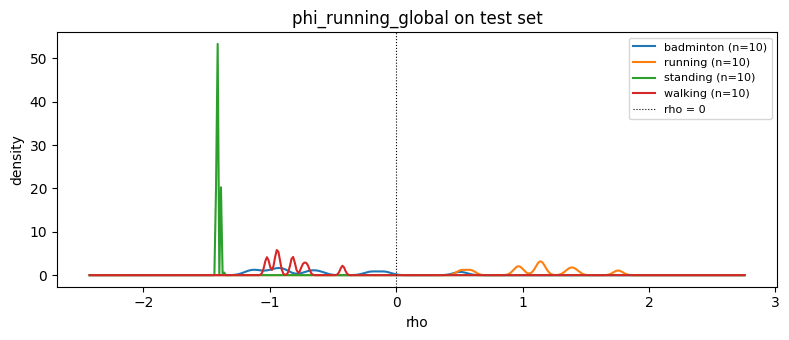

( ( ( G[32,inf](x_4 <= 0.9257) ) ∧ ( F[16,64]( F[30,inf]( ( (x_0 => -0.0909) ∨ (x_1 => 0.6823) ) ∧ (x_1 => -0.6809) ) ) ) ) ∨ ( ( G[32,inf](x_0 <= 0.9164) ) ∧ ( F[64,inf]( (x_5 => 0.3517) ∨ ( (x_5 => 2.4201) ∧ (x_1 => -1.8853) ) ) ) ) )


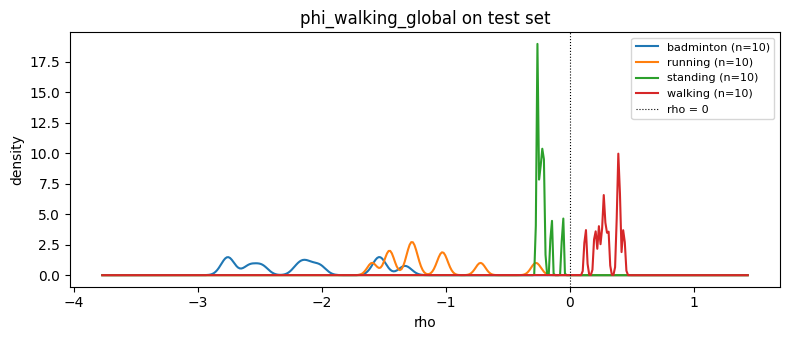

( ( ( G[9,10]( (x_4 <= 6.3449) ∧ ( (x_0 => 4.69) ∨ (x_4 => 5.5372) ) ) ) ∨ ( F(x_4 <= -3.8095) ) ) ∨ ( F( ( (x_3 <= -3.8601) ∨ (x_5 <= -4.1639) ) ∨ (x_3 <= -10.0277) ) ) )


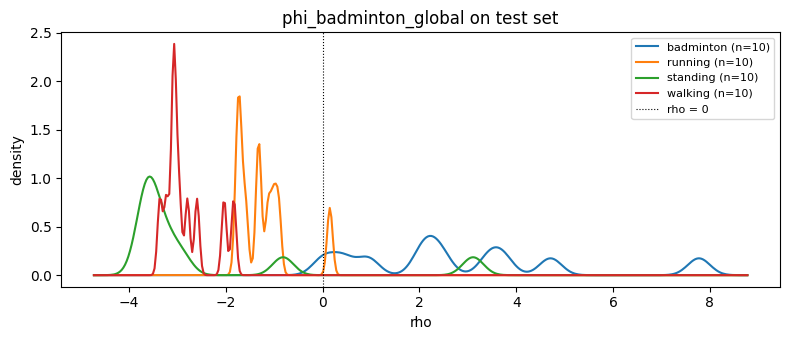

In [27]:
def evaluate_global(global_per_class, n_unique_per_class, X_eval_t, y_eval):
    print(f"{'class':<12s} {'#unique':>8s} {'coverage':>10s} {'FP rate':>10s}")
    print("-" * 44)
    for cls, phi_global in global_per_class.items():
        rho = eval_robustness(phi_global, X_eval_t)
        target_mask = (y_eval == cls)
        coverage = (rho[target_mask] > 0).mean() if target_mask.any() else float("nan")
        fp_rate  = (rho[~target_mask] > 0).mean() if (~target_mask).any() else float("nan")
        print(f"{cls:<12s} {n_unique_per_class[cls]:>8d} {coverage:>9.1%} {fp_rate:>9.1%}")


print("Evaluation on test set:")
evaluate_global(global_per_class, n_unique_per_class, X_te, y_te)

for cls, phi_global in global_per_class.items():
    print(phi_global)
    plot_robustness_kde(
        phi_global, X_te, y_te, classes,
        title=f"phi_{cls}_global on test set",
    )